# Contexte du projet — Rakuten France Multimodal Product Data Classification

## Contexte métier

**Rakuten France** est une plateforme de e-commerce sur laquelle des millions de vendeurs publient des annonces de produits.  
Chaque annonce contient un titre (désignation), une description textuelle optionnelle et une image du produit.

L'enjeu opérationnel est de **catégoriser automatiquement ces produits** pour améliorer la recherche, la recommandation et l'organisation du catalogue.  
Ce challenge, proposé sur la plateforme **ENS Challenge Data**, demande de prédire le type de produit parmi **27 catégories** à partir de données textuelles et visuelles.

---

## Données disponibles

| Fichier | Contenu |
|---|---|
| `X_train_update.csv` | Features : `designation`, `description`, `productid`, `imageid` |
| `Y_train_CVw08PX.csv` | Labels : `prdtypecode` (27 classes) |
| `images/image_train/` | Photos des produits (une par `imageid`) |

---

## Pipeline du projet

```
Données brutes (texte + images)
        │
        ▼
1. Exploration
        │
        ▼
2. Préprocessing texte          +        Préprocessing images
        │                                         │
        ▼                                         ▼
3. Modelisation texte                        Modelisation images
        │                                         │
        └─────────────────┬───────────────────────┘
                          ▼
                4. Fusion multimodale
                          │
                          ▼
                5. Évaluation & interprétation
```

---

## Métrique d'évaluation

Le challenge est évalué sur le **weighted F1-score**, ce qui pénalise les erreurs sur toutes les classes proportionnellement à leur fréquence — important vu le fort déséquilibre des classes.

---

## Objectif de ce notebook

Explorer le jeu de données pour comprendre :
- La structure et la qualité des données
- La distribution des classes (déséquilibre)
- Les caractéristiques des champs texte par classe
- Les décisions de préprocessing à prendre

---

# Exploration des Données

In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. Chargement des données

On importe les bibliothèques nécessaires et on charge le fichier `X_train_update.csv` qui contient les **features** : la désignation du produit, sa description, un identifiant produit et un identifiant image.
On remarquera que la designation du 1er produit est en allemand; on gardera l'hypothèse que les champs Text sont en plusieurs langues.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("../data/X_train_update.csv", index_col=0)
df.head()

,designation,description,productid,imageid
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786


## 2. Structure du jeu de données

`df.info()` donne un aperçu rapide des types de colonnes et du nombre de valeurs non-nulles.  
On voit que le dataset contient **84 916 lignes** et 4 colonnes.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84916 entries, 0 to 84915
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   designation  84916 non-null  str  
 1   description  55116 non-null  str  
 2   productid    84916 non-null  int64
 3   imageid      84916 non-null  int64
dtypes: int64(2), str(2)
memory usage: 2.6 MB


## 3. Qualité des données

On construit un tableau récapitulatif pour chaque colonne : type, nombre de valeurs non-nulles, nombre de valeurs manquantes, pourcentage de valeurs manquantes, et cardinalité.

**Observations clés :**
- `designation` : toujours renseignée — c'est la colonne texte principale.
- `description` : **35 % de valeurs manquantes** — à traiter lors du préprocessing.
- `productid` et `imageid` : identifiants uniques, pas de doublons.

In [4]:
quality = pd.DataFrame({
    'dtype':       df.dtypes,
    'non_null':    df.notna().sum(),
    'null':        df.isna().sum(),
    'null_%':      (df.isna().mean() * 100).round(1),
    'n_unique':    df.nunique(),
})
quality

,dtype,non_null,null,null_%,n_unique
designation,str,84916,0,0.0,82265
description,str,55116,29800,35.1,47506
productid,int64,84916,0,0.0,84916
imageid,int64,84916,0,0.0,84916


## 4. Variable cible

On charge le fichier `Y_train_CVw08PX.csv` qui contient les **labels** : la colonne `prdtypecode` représente le code de catégorie produit.  
Il y a **27 classes** au total.

In [5]:
df_y = pd.read_csv("../data/Y_train_CVw08PX.csv", index_col=0)
display(df_y.head())
print(df_y.nunique())

,prdtypecode
0,10
1,2280
2,50
3,1280
4,2705


prdtypecode    27
dtype: int64


### Distribution des classes

On examine le nombre d'exemples par classe pour détecter un éventuel **déséquilibre**.  
La classe la plus fréquente (`2583`) contient ~10 200 exemples, la moins fréquente (`1180`) seulement ~760 — soit un rapport de **1 à 13**.

In [6]:
df_y['prdtypecode'].value_counts().sort_values(ascending=False)

prdtypecode
2583    10209
1560     5073
1300     5045
2060     4993
2522     4989
1280     4870
2403     4774
2280     4760
1920     4303
1160     3953
1320     3241
10       3116
2705     2761
1140     2671
2582     2589
40       2508
2585     2496
1302     2491
1281     2070
50       1681
2462     1421
2905      872
60        832
2220      824
1301      807
1940      803
1180      764
Name: count, dtype: int64

### Visualisation de la distribution des classes

Un graphique en barres permet de visualiser directement le déséquilibre entre les catégories.  


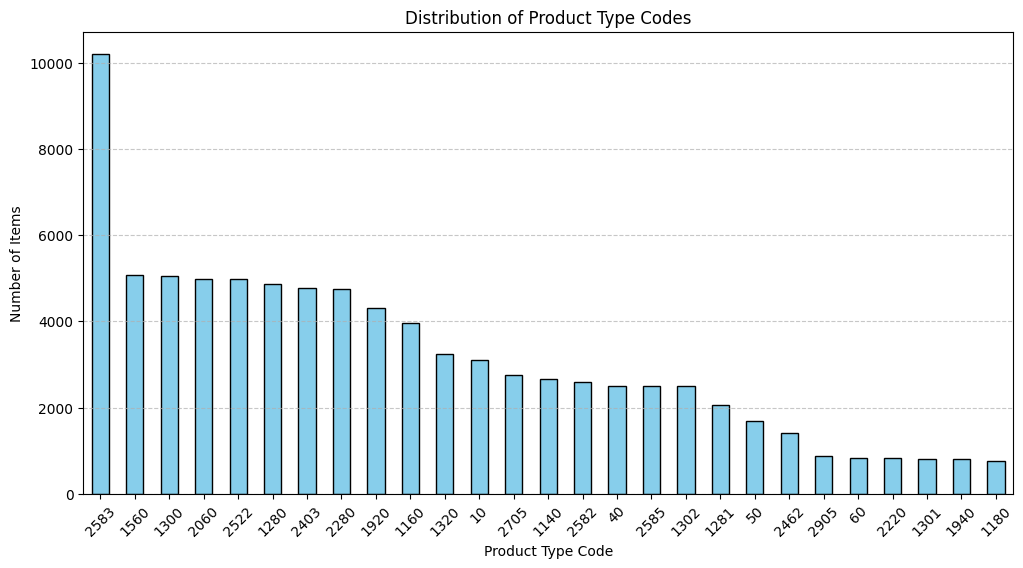

In [8]:
plt.figure(figsize=(12, 6))

code_counts = df_y['prdtypecode'].value_counts()

code_counts.plot(kind='bar',color='skyblue', edgecolor='black')

plt.title('Distribution of Product Type Codes')
plt.xlabel('Product Type Code')
plt.ylabel('Number of Items')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)



## 5. Analyse croisée X et Y

On joint les features (`df`) et les labels (`df_y`) sur l'index commun pour pouvoir analyser les données **par classe**.  
On utilise `how="inner"` pour ne conserver que les lignes présentes dans les deux fichiers.  
On recalcule ensuite le tableau de qualité sur le dataset fusionné pour vérifier l'intégrité de la jointure.

In [ ]:
data = df.join(df_y, how="inner")

quality = pd.DataFrame({
    'dtype':       data.dtypes,
    'non_null':    data.notna().sum(),
    'null':        data.isna().sum(),
    'null_%':      (data.isna().mean() * 100).round(1),
    'n_unique':    data.nunique(),
})
quality

,dtype,non_null,null,null_%,n_unique
designation,str,84916,0,0.0,82265
description,str,55116,29800,35.1,47506
productid,int64,84916,0,0.0,84916
imageid,int64,84916,0,0.0,84916
prdtypecode,int64,84916,0,0.0,27


### Valeurs manquantes dans `description` par classe

On calcule le **taux de valeurs manquantes** dans la colonne `description` pour chaque catégorie.

**Observations clés :**
- Certaines classes (ex. `2403`, `2462`, `2280`) ont plus de **90 % de descriptions vides** — elles s'appuient presque exclusivement sur la `designation`.
- D'autres classes (ex. `2905`, `2582`) ont très peu de valeurs manquantes — la description y est systématiquement renseignée.
- Cette hétérogénéité est importante : la stratégie de remplacement des valeurs manquantes devra être adaptée classe par classe.

In [ ]:
data.groupby('prdtypecode')['description'].apply(lambda x: x.isna().mean() * 100).round(1).sort_values(ascending=False)


prdtypecode
2403    97.4
2462    96.3
2280    93.3
1160    91.2
10      89.2
1180    80.0
40      65.5
1140    64.6
2705    37.1
1320    34.0
50      28.3
1281    23.8
2522    23.8
1300    23.3
1280    21.9
60      16.0
1301    13.0
1302    11.1
2583     8.8
2220     8.0
2585     7.9
2060     5.7
1940     5.6
1920     4.8
1560     3.5
2582     2.4
2905     0.0
Name: description, dtype: float64

### Longueur des textes par classe

On calcule le nombre moyen de mots dans `designation` et `description` pour chaque catégorie.

**Observations clés :**
- Les classes `2280` et `60` ont les désignations les plus longues (~18–19 mots en moyenne).
- La classe `2705` a les désignations les plus courtes (~6 mots) — probablement des produits avec un nom très concis.
- La classe `2905` se démarque par des descriptions très longues (~365 mots) malgré des désignations courtes.

In [ ]:
data['desig_len'] = data['designation'].str.split().str.len()
data['desc_len']  = data['description'].str.split().str.len()

data.groupby('prdtypecode')[['desig_len', 'desc_len']].mean().sort_values('desig_len', ascending=False).astype('int64')


,desig_len,desc_len
prdtypecode,,
2280,19,38
60,18,35
1300,13,152
1560,13,145
2060,12,164
2585,12,139
2403,12,36
2582,11,129
2522,11,50


ANALYSE APPROFONDIE DES DOUBLONS

Doublons de lignes entières

In [ ]:
print("Doublons de lignes entières :", df.duplicated().sum())

NameError: name 'df' is not defined